In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.corpus import stopwords

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vaishnavi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [5]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
fake["label"] = 0
true["label"] = 1

In [8]:
data = pd.concat([fake, true], axis=0)

In [9]:
data = data[['text', 'label']]

In [10]:
data.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [11]:
data.shape

(44898, 2)

In [12]:
stop_words = set(stopwords.words('english'))

In [13]:
def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [14]:
data['text'] = data['text'].apply(clean_text)

In [15]:
data.head()

,text,label
0,donald trump wish americans happy new year lea...,0
1,house intelligence committee chairman devin nu...,0
2,friday revealed former milwaukee sheriff david...,0
3,christmas day donald trump announced would bac...,0
4,pope francis used annual christmas day message...,0


In [16]:
X = data['text']
y = data['label']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [18]:
vectorizer = TfidfVectorizer(max_df=0.7)

In [19]:
Xv_train = vectorizer.fit_transform(X_train)
Xv_test = vectorizer.transform(X_test)

In [20]:
print(Xv_train.shape)

(33673, 180903)


In [34]:
model = LogisticRegression(max_iter=1000)

In [35]:
model.fit(Xv_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
predictions = model.predict(Xv_test)

In [37]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9860133630289533


In [38]:
cm = confusion_matrix(y_test, predictions)

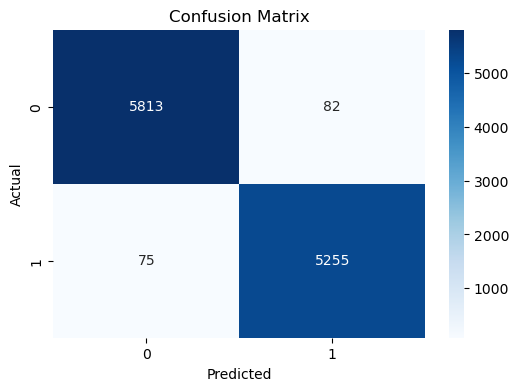

In [39]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
def predict_news(news):
    
    # clean text
    cleaned_news = clean_text(news)
    
    # vectorize
    vectorized_news = vectorizer.transform([cleaned_news])
    
    # predict
    prediction = model.predict(vectorized_news)
    
    if prediction[0] == 0:
        return "Fake News"
    else:
        return "Real News"

In [41]:
sample_news = "NASA confirms humans landed on Mars yesterday."

print(predict_news(sample_news))

Fake News


In [42]:
sample_news = "The government announced new education policies today."

print(predict_news(sample_news))

Fake News


In [43]:
sample_news = "Aliens elected as presidents in Europe."

print(predict_news(sample_news))

Fake News


In [44]:
sample_news = "The Reserve Bank of India announced a revision in repo rates during the monetary policy meeting."

print(predict_news(sample_news))

Fake News


In [45]:
sample_news = "The United Nations held a climate summit to discuss global carbon emissions."

print(predict_news(sample_news))

Fake News


In [33]:
sample_news = "Researchers at MIT published a study on artificial intelligence and healthcare applications."

print(predict_news(sample_news))

Fake News


In [46]:
sample_news = """
The Indian Space Research Organisation announced the successful testing 
of a reusable launch vehicle during trials conducted on Saturday. 
Officials stated that the mission achieved all planned objectives.
"""

print(predict_news(sample_news))

Fake News


In [47]:
print(data['label'].value_counts())

0    23481
1    21417
Name: label, dtype: int64


In [48]:
np.unique(predictions)

array([0, 1], dtype=int64)

In [49]:
real_article = true.iloc[0]['text']

print(predict_news(real_article))

Real News


In [50]:
fake_article = fake.iloc[0]['text']

print(predict_news(fake_article))

Fake News


In [51]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5895
           1       0.98      0.99      0.99      5330

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



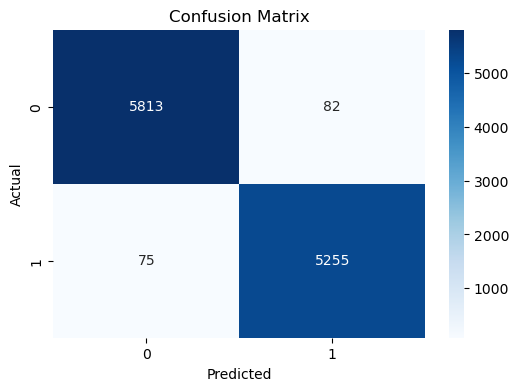

In [52]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [53]:
data.head()

,text,label
0,donald trump wish americans happy new year lea...,0
1,house intelligence committee chairman devin nu...,0
2,friday revealed former milwaukee sheriff david...,0
3,christmas day donald trump announced would bac...,0
4,pope francis used annual christmas day message...,0
